# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Ida Bagus Gede Widiastana Bawaskara
- **Email:** bawaskara30@gmail.com
- **ID Dicoding:** widiastana

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana pola penyewaan sepeda antara pengguna Casual dan Registered berdasarkan kategori waktu aktivitas (Pagi, Siang, Sore, Malam) sepanjang tahun 2011-2012?
- **Pertanyaan 2:** Sejauh mana pengaruh kategori suhu udara (Rendah, Sedang, Tinggi) terhadap rata-rata total penyewaan sepeda harian (cnt) selama periode 2011-2012?
- **Pertanyaan 3:** Apakah terdapat perbedaan yang signifikan pada volume penyewaan pengguna Casual dibandingkan Registered saat hari kerja (workingday) berhadapan dengan hari libur/akhir pekan?

## Import Semua Packages/Library yang Digunakan

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

**1. Memuat Data Harian**

In [86]:
day_df = pd.read_csv("data/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Kolom parameter lingkungan seperti suhu (temp), suhu terasa (atemp), kelembapan (hum), dan kecepatan angin (windspeed) disajikan dalam bentuk angka desimal berskala 0 hingga 1 yang mengindikasikan bahwa data tersebut sudah melalui proses normalisasi (min-max scaling).
- Terdapat pemisahan yang sangat jelas antara metrik pengguna casual dan registered untuk menjawab Pertanyaan Bisnis 3, dengan langsung membandingkan perilaku kedua kelompok ini berdasarkan kolom workingday atau holiday.

**2. Memuat Data Per Jam**

In [87]:
hour_df = pd.read_csv("data/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Kolom (hr) ini adalah fitur krusial yang akan kita gunakan untuk melakukan teknik analisis lanjutan berupa *Manual Grouping* (Clustering). Kita akan mengonversi rentang angka jam ini menjadi kategori waktu aktivitas (Pagi, Siang, Sore, Malam) guna menjawab Pertanyaan Bisnis 1
- Terlihat adanya fluktuasi detail pada metrik penyewaan (cnt). Pada baris data awal misalnya jam 04:00 pagi, jumlah peminjam sangat rendah hanya 1 (registered) dan 0 (casual). Hal ini memperkuat hipotesis awal bahwa waktu memegang peranan krusial dalam kebiasaan penyewaan sepeda.

### Assessing Data

**1. Data Harian**

In [88]:
# Memeriksa tipe data dan informasi umum dari day_df
day_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB


In [89]:
# Memeriksa apakah ada baris data yang duplikat
print("Jumlah duplikasi data pada day_df: ", day_df.duplicated().sum())

Jumlah duplikasi data pada day_df:  0


In [90]:
# Memeriksa ringkasan parameter statistik untuk mendeteksi keanehan (outlier/invalid value)
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take Untuk Data Harian:**
- Mengubah tipe data pada kolom dteday dari str (string/object) menjadi datetime menggunakan pd.to_datetime() untuk mempermudah manipulasi analisis deret waktu.
- Memetakan (mapping) nilai integer pada kolom kategorikal seperti season, weathersit, dan weekday menjadi nilai teks yang deskriptif

**Insight Dari Data Harian:** 
- kebersihan day_df sudah sangat baik, terbukti dari nihilnya missing values dan duplikat
- Terdapat fluktuasi yang sangat ekstrem pada kolom target cnt, dengan rekor peminjaman terendah hanya 22 unit dan titik puncak mencapai 8.714 unit dalam sehari.

**2. Data Per Jam**

In [91]:
# Memeriksa tipe data dan informasi umum dari hour_df
hour_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


In [92]:
# Memeriksa apakah ada baris data yang duplikat
print("Jumlah duplikasi data pada hour_df: ", hour_df.duplicated().sum())

Jumlah duplikasi data pada hour_df:  0


In [93]:
# Memeriksa ringkasan parameter statistik untuk mendeteksi keanehan (outlier/invalid value)
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take Untuk Data Per Jam:**
- hampir sama dengan data harian. Mengubah tipe data pada kolom dteday dari str (string/object) menjadi datetime menggunakan pd.to_datetime() untuk mempermudah manipulasi analisis deret waktu.
- elakukan Manual Grouping (Clustering) pada kolom (hr)

**Insight Dari Data Per Jam:** 
- Fluktuasi penyewaan (cnt) pada skala per jam sangat tajam, bergerak dari titik terendah 1 unit hingga puncak 977 unit dalam satu jam tertentu.
- Nilai maksimal peminjaman per jam oleh pengguna registered mencapai 886 unit, jauh melampaui puncak peminjaman pengguna casual yang hanya menyentuh 367 unit.

### Cleaning Data

**1. Membersihkan Data Harian dan Implementasi Binning temp Untuk Q2**

In [94]:
# 1. Mengubah tipe data dteday
day_df["dteday"] = pd.to_datetime(day_df["dteday"])

# 2. Menghapus kolom instant
day_df.drop("instant", axis=1, inplace=True)

# 3. Memetakan nilai kategorikal
# season
day_df["season"] = day_df["season"].map({
  1: "Spring", 
  2: "Summer", 
  3: "Fall", 
  4: "Winter"
})

# weathersit
day_df["weathersit"] = day_df["weathersit"].map({
  1: "Clear", 
  2: "Misty", 
  3: "Light Rain/Snow", 
  4: "Heavy Rain/Snow"
})

#weekday
day_df["weekday"] = day_df["weekday"].map({
  0: "Sunday", 
  1: "Monday", 
  2: "Tuesday", 
  3: "Wednesday", 
  4: "Thursday", 
  5: "Friday", 
  6: "Saturday"
})

# Mapping workingday khusus untuk menjawab Q3
day_df["workingday"] = day_df["workingday"].map({
  0: "Akhir Pekan/Libur", 
  1: "Hari Kerja"
})

# 4. [Binning Q2] Membagi suhu (temp) menjadi 3 kategori: Rendah, Sedang, Tinggi
# Menggunakan pd.cut untuk membagi rentang desimal menjadi 3 bagian yang sama besar
day_df["temp_category"] = pd.cut(day_df["temp"], bins=3, labels=["Rendah", "Sedang", "Tinggi"])

# Mengecek hasil pembersihan day_df
day_df[["dteday", "temp", "temp_category", "workingday", "cnt"]].head()

,dteday,temp,temp_category,workingday,cnt
0,2011-01-01,0.344167,Sedang,Akhir Pekan/Libur,985
1,2011-01-02,0.363478,Sedang,Akhir Pekan/Libur,801
2,2011-01-03,0.196364,Rendah,Hari Kerja,1349
3,2011-01-04,0.200000,Rendah,Hari Kerja,1562
4,2011-01-05,0.226957,Rendah,Hari Kerja,1600


**Insight Hasil Cleaning Data Harian:**
- Format dteday sudah menjadi standar penanggalan yang benar, dan label pada workingday ("Akhir Pekan/Libur" vs "Hari Kerja") sudah mudah untuk dipahami
- Kolom baru temp_category telah dibuat dan berhasil mengklasifikasikan nilai desimal suhu secara otomatis

**2. Membersihkan Data Per Jam dan Implementasi Grouping Untuk Q1**

In [95]:
# 1. Mengubah tipe data dteday
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# 2. Menghapus kolom instant
hour_df.drop("instant", axis=1, inplace=True)

# 3. Memetakan nilai kategorikal
# season
hour_df["season"] = hour_df["season"].map({
  1: "Spring", 
  2: "Summer", 
  3: "Fall", 
  4: "Winter"
})

# weathersit
hour_df["weathersit"] = hour_df["weathersit"].map({
  1: "Clear", 
  2: "Misty", 
  3: "Light Rain/Snow", 
  4: "Heavy Rain/Snow"
})

#weekday
hour_df["weekday"] = hour_df["weekday"].map({
  0: "Sunday", 
  1: "Monday", 
  2: "Tuesday", 
  3: "Wednesday", 
  4: "Thursday", 
  5: "Friday", 
  6: "Saturday"
})

# workingday
hour_df["workingday"] = hour_df["workingday"].map({
  0: "Akhir Pekan/Libur", 
  1: "Hari Kerja"
})

# 4. [Grouping Q1] Mengelompokkan jam menjadi Pagi, Siang, Sore, Malam
def categorize_time(hour):
    if 5 <= hour <= 10:
        return "Pagi"
    elif 11 <= hour <= 15:
        return "Siang"
    elif 16 <= hour <= 20:
        return "Sore"
    else:
        return "Malam"

hour_df["time_category"] = hour_df["hr"].apply(categorize_time)

# Mengecek hasil pembersihan hour_df
hour_df[["dteday", "hr", "time_category", "casual", "registered"]].head()

,dteday,hr,time_category,casual,registered
0,2011-01-01,0,Malam,3,13
1,2011-01-01,1,Malam,8,32
2,2011-01-01,2,Malam,5,27
3,2011-01-01,3,Malam,3,10
4,2011-01-01,4,Malam,0,1


**Insight Hasil Cleaning Data Per Jam:**
- Pembuatan fitur baru (time_category) telah berjalan sempurna. Jam operasional (seperti jam 0 hingga 4 pada sampel) sudah terklasifikasi otomatis sebagai "Malam".
- Terlihat pada sampel data dini hari atau Malam, jumlah penyewaan oleh pengguna casual maupun registered sangat minim yang menandakan data terekam secara logis.

## Exploratory Data Analysis (EDA)

**1. Pola Penyewaan (Casual vs Registered) Berdasarkan Kategori Waktu**

In [96]:
# Mengelompokkan data berdasarkan time_category dan menghitung total pengguna casual dan registered
time_analysis_df = hour_df.groupby(by="time_category").agg({
    "casual": "sum",
    "registered": "sum",
    "cnt": "sum"
}).sort_values(by="cnt", ascending=False)

# Menampilkan hasil
time_analysis_df

,casual,registered,cnt
time_category,,,
Sore,214433,1051286,1265719
Siang,255412,624042,879454
Pagi,84074,686186,770260
Malam,66098,311148,377246


**Insight:**
- Kategori waktu "Sore" merupakan periode operasional tersibuk dengan lebih dari 1 juta total penyewaan (cnt).
- Pengguna registered mendominasi di seluruh waktu, namun lonjakan utamanya terjadi pada "Sore" (848.518 penyewaan) dan "Pagi" (598.393 penyewaan). Pola ini sangat identik dengan aktivitas berangkat dan pulang dari tempat kerja.
- Berbeda dengan pengguna terdaftar, pengguna casual justru sangat sedikit di "Pagi" hari (hanya 61.080 penyewaan), dan baru menunjukkan peningkatan aktivitas pada "Siang" dan "Sore" hari. Hal ini mengonfirmasi bahwa segmen casual cenderung menggunakan sepeda untuk rekreasi, jalan-jalan siang, atau aktivitas non-rutin, bukan untuk mobilitas utama.

**2. Pengaruh Kategori Suhu Terhadap Total Penyewaan Harian**

In [97]:
# Mengelompokkan data berdasarkan temp_category dan melihat statistik (rata-rata, max, min) dari total penyewaan
temp_analysis_df = day_df.groupby(by="temp_category").agg({
    "cnt": ["mean", "max", "min", "count"]
})

# Menampilkan hasil
temp_analysis_df

cnt                  
                      mean   max   min count
temp_category                               
Rendah         2569.005882  5686   431   170
Sedang         4599.000000  8555    22   297
Tinggi         5644.109848  8714  1115   264

**Insight:**
- Terdapat lonjakan rata-rata penyewaan yang sangat jelas seiring dengan naiknya suhu udara. Ini mengonfirmasi bahwa cuaca hangat adalah pendorong utama orang untuk bersepeda.
- Kategori suhu Tinggi menjadi kondisi paling optimal bagi bisnis, mencetak rekor penyewaan maksimal tertinggi dengan 8.714 unit dan batas bawah (min) yang cukup aman 1.115 unit. Sebaliknya, suhu Rendah sangat menekan minat bersepeda, di mana rekor maksimalnya hanya 5.686 unit.

**3. Perilaku Penyewaan Berdasarkan Hari Kerja vs Hari Libur**

In [98]:
# Mengelompokkan data berdasarkan workingday dan menghitung total penyewaan pengguna casual dan registered
day_type_analysis_df = day_df.groupby(by="workingday").agg({
    "casual": "sum",
    "registered": "sum",
    "cnt": "sum"
}).sort_values(by="cnt", ascending=False)

# Menampilkan hasil
day_type_analysis_df

,casual,registered,cnt
workingday,,,
Hari Kerja,303285,1989125,2292410
Akhir Pekan/Libur,316732,683537,1000269


**Insight:**
- Pengguna terdaftar menyumbang volume penyewaan yang masif pada "Hari Kerja" hampir 2 juta penyewaan.
- jumlah penyewaan pengguna casual pada "Akhir Pekan/Libur" dengan 316.732 unit ternyata lebih tinggi dibandingkan total seluruh "Hari Kerja" dengan 303.285 unit.

## Visualization & Explanatory Analysis

### **Pertanyaan 1:** Bagaimana pola penyewaan sepeda antara pengguna Casual dan Registered berdasarkan kategori waktu aktivitas (Pagi, Siang, Sore, Malam) sepanjang tahun 2011-2012?

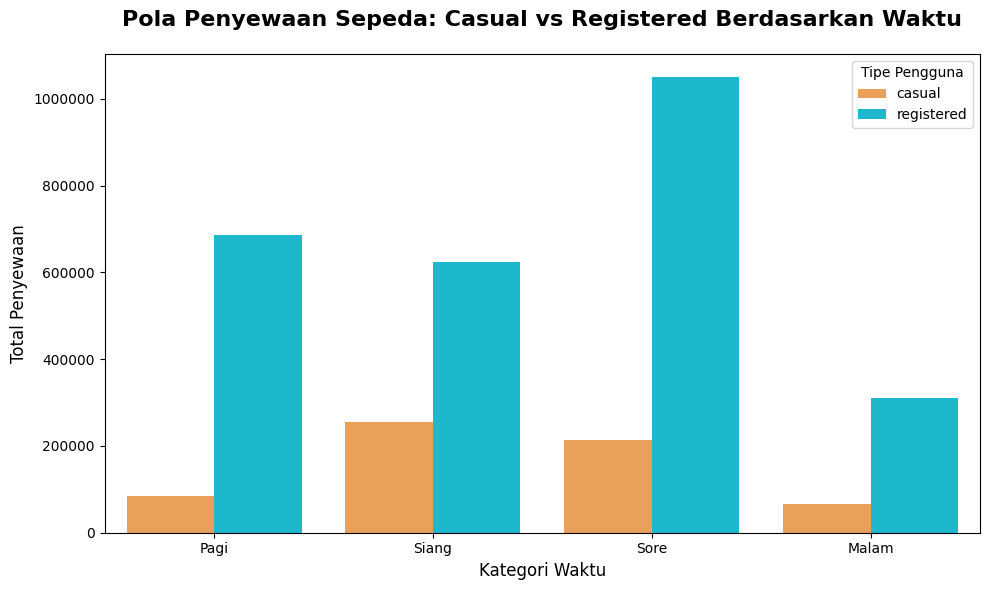

In [99]:
# Mengurutkan kategori waktu secara kronologis
time_order = ['Pagi', 'Siang', 'Sore', 'Malam']

# Mereset index dan me-melt dataframe agar sesuai format seaborn (long format)
time_melted = time_analysis_df.reset_index().melt(
    id_vars=['time_category'], 
    value_vars=['casual', 'registered'], 
    var_name='Tipe Pengguna', 
    value_name='Total Penyewaan'
)

# Membuat kanvas visualisasi
plt.figure(figsize=(10, 6))

# Membuat Grouped Bar Chart
sns.barplot(
    x='time_category', 
    y='Total Penyewaan', 
    hue='Tipe Pengguna', 
    data=time_melted, 
    order=time_order,
    palette=['#FF9F43', '#00CFE8'] # Warna Oranye untuk Casual, Biru untuk Registered
)

# Menambahkan judul dan label yang deskriptif
plt.title('Pola Penyewaan Sepeda: Casual vs Registered Berdasarkan Waktu', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Kategori Waktu', fontsize=12)
plt.ylabel('Total Penyewaan', fontsize=12)

# Mematikan notasi ilmiah pada sumbu Y agar angka terbaca jelas
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

**Insight Q1:** 
- Pengguna Registered (biru) mendominasi di seluruh waktu operasional, dengan dua puncak tertinggi terjadi pada rentang "Sore" dan "Pagi". Pola ini sangat mencerminkan aktivitas berangkat kerja atau ke kampus di pagi hari dan pulang di sore hari.
- Pengguna Casual (oranye) menunjukkan tingkat penyewaan yang sangat rendah di "Pagi" hari namun, tinggi pada "Siang" dan "Sore" hari. Pola ini menegaskan bahwa segmen casual lebih condong menggunakan sepeda untuk tujuan rekreasi atau olahraga santai yang umumnya dilakukan saat cuaca lebih hangat.

### **Pertanyaan 2:** Sejauh mana pengaruh kategori suhu udara (Rendah, Sedang, Tinggi) terhadap rata-rata total penyewaan sepeda harian (cnt) selama periode 2011-2012?

C:\Users\Pongo\AppData\Local\Temp\ipykernel_9464\2492167666.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\Pongo\AppData\Local\Temp\ipykernel_9464\2492167666.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


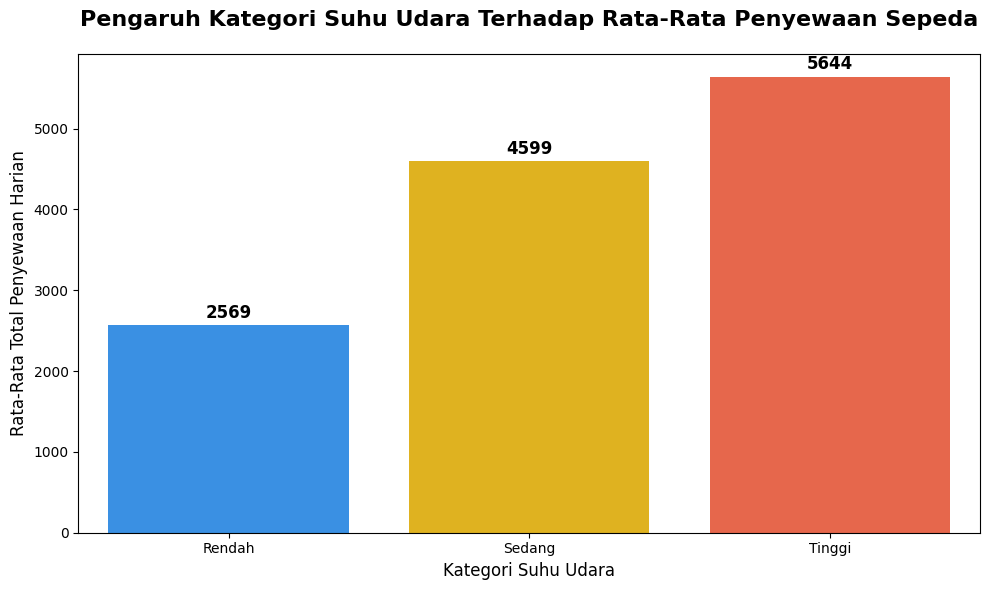

In [100]:
# Menyiapkan urutan kategori dan warna Biru=Dingin, Kuning=Sedang, Merah=Panas
temp_order = ['Rendah', 'Sedang', 'Tinggi']
temp_colors = ['#1E90FF', '#FFC300', '#FF5733'] 

plt.figure(figsize=(10, 6))

# Membuat Bar Plot
sns.barplot(
    x='temp_category', 
    y='cnt', 
    data=day_df, 
    order=temp_order,
    palette=temp_colors,
    ci=None # Menghilangkan garis confidence interval agar clean
)

# Menambahkan anotasi label angka tepat di atas masing-masing bar
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

# Menambahkan judul dan label yang deskriptif
plt.title('Pengaruh Kategori Suhu Udara Terhadap Rata-Rata Penyewaan Sepeda', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Kategori Suhu Udara', fontsize=12)
plt.ylabel('Rata-Rata Total Penyewaan Harian', fontsize=12)

plt.tight_layout()
plt.show()

**Insight Q2:**
- Grafik menunjukkan tren peningkatan, rata-rata penyewaan sepeda melonjak tajam seiring dengan menghangatnya suhu udara.
- Kondisi cuaca dingin/suhu rendah terbukti menjadi hambatan terbesar bagi pengguna untuk menyewa sepeda.

### **Pertanyaan 3:** Apakah terdapat perbedaan yang signifikan pada volume penyewaan pengguna Casual dibandingkan Registered saat hari kerja (workingday) berhadapan dengan hari libur/akhir pekan?

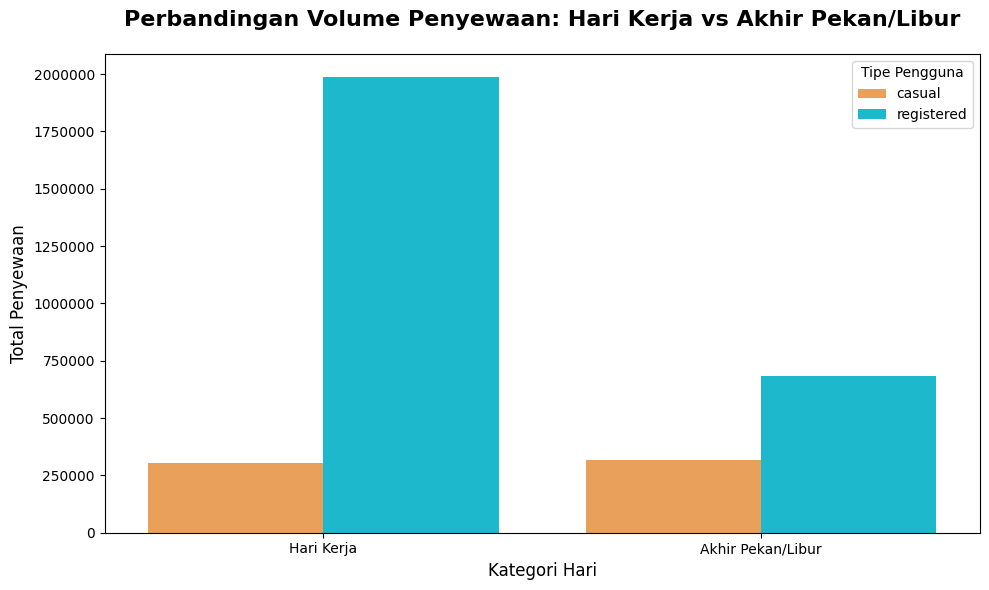

In [101]:
# Mereset index dan me-melt dataframe agar sesuai format seaborn (long format)
day_type_melted = day_type_analysis_df.reset_index().melt(
    id_vars=['workingday'], 
    value_vars=['casual', 'registered'], 
    var_name='Tipe Pengguna', 
    value_name='Total Penyewaan'
)

# Membuat kanvas visualisasi
plt.figure(figsize=(10, 6))

# Membuat Grouped Bar Chart
sns.barplot(
    x='workingday', 
    y='Total Penyewaan', 
    hue='Tipe Pengguna', 
    data=day_type_melted, 
    palette=['#FF9F43', '#00CFE8'] # Warna konsisten dengan grafik Q1
)

# Menambahkan judul dan label
plt.title('Perbandingan Volume Penyewaan: Hari Kerja vs Akhir Pekan/Libur', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Kategori Hari', fontsize=12)
plt.ylabel('Total Penyewaan', fontsize=12)

# Mematikan notasi ilmiah pada sumbu Y
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

**Insight Q3:**
- Pengguna Registered (biru) menyumbang volume penyewaan yang sangat masif pada "Hari Kerja", hampir menyentuh angka 2 juta unit. Visualisasi ini memvalidasi dengan sangat jelas bahwa fungsi utama sepeda bagi kelompok ini adalah sebagai alat transportasi harian (bekerja atau sekolah).
- Meskipun jumlah "Akhir Pekan/Libur" jauh lebih sedikit dibandingkan "Hari Kerja" dalam setahun, total penyewaan casual (orange) di hari libur justru sedikit lebih tinggi. Ini membuktikan bahwa segmen Casual sangat sensitif terhadap hari libur dan menjadikan aktivitas bersepeda murni sebagai sarana rekreasi atau olahraga santai akhir pekan.

## Analisis Lanjutan (Opsional)

- Mengelompokkan hari-hari penyewaan menjadi kategori "Sepi", "Normal", dan "Ramai" berdasarkan jumlah total penyewaan (cnt), lalu melihat faktor apa yang membuat suatu hari menjadi sangat ramai.

In [102]:
# --- MEMBUAT CLUSTERING MANUAL (BINNING) ---

# Mengelompokkan hari berdasarkan jumlah penyewaan (cnt) menjadi 3 kategori
day_df['rental_category'] = pd.qcut(day_df['cnt'], q=3, labels=['Sepi', 'Normal', 'Ramai'])

# Melihat sebaran datanya
print("Distribusi Kategori Hari Penyewaan:")
print(day_df['rental_category'].value_counts())

# Menghitung rata-rata penyewaan untuk casual dan registered di tiap kategori
clustering_summary = day_df.groupby('rental_category')[['casual', 'registered', 'cnt']].mean().reset_index()
print("\nRingkasan Rata-rata per Kategori:")
print(clustering_summary)

Distribusi Kategori Hari Penyewaan:
rental_category
Sepi      244
Normal    244
Ramai     243
Name: count, dtype: int64

Ringkasan Rata-rata per Kategori:
  rental_category       casual   registered          cnt
0            Sepi   333.381148  1978.684426  2312.065574
1          Normal   842.963115  3679.262295  4522.225410
2           Ramai  1370.325103  5317.378601  6687.703704


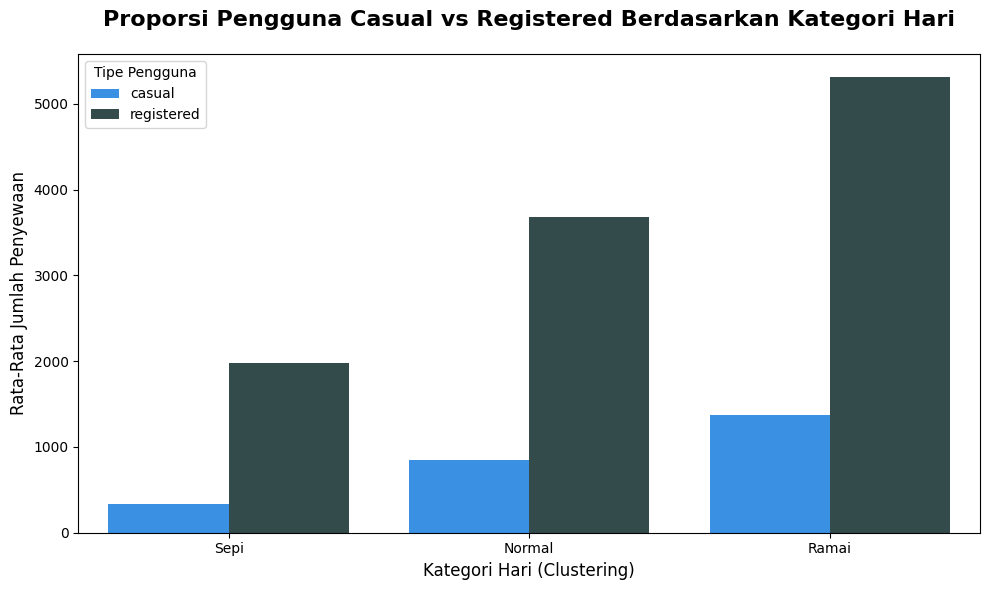

In [103]:
# --- VISUALISASI HASIL CLUSTERING ---

# Mengubah format data agar lebih mudah divisualisasikan dengan Seaborn (Melt)
melted_df = day_df.melt(
    id_vars=['rental_category'], 
    value_vars=['casual', 'registered'], 
    var_name='Tipe Pengguna', 
    value_name='Jumlah Penyewaan'
)

plt.figure(figsize=(10, 6))

# Warna biru untuk Registered dan abu-abu gelap untuk Casual
user_colors = ['#1E90FF', '#2F4F4F']

# Membuat Bar Plot kelompok
sns.barplot(
    x='rental_category', 
    y='Jumlah Penyewaan', 
    hue='Tipe Pengguna', 
    data=melted_df, 
    palette=user_colors,
    errorbar=None
)

# Menambahkan detail UI visual
plt.title('Proporsi Pengguna Casual vs Registered Berdasarkan Kategori Hari', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Kategori Hari (Clustering)', fontsize=12)
plt.ylabel('Rata-Rata Jumlah Penyewaan', fontsize=12)
plt.legend(title='Tipe Pengguna', loc='upper left')

plt.tight_layout()
plt.show()

**Insight :**
- Pelanggan registered selalu mendominasi jumlah penyewaan dibandingkan penlanggan casual di semua kategori hari.
- Terdapat tren kenaikan yang konsisten pada kedua kelompok pengguna. Saat hari berubah, jumlah penyewaan oleh casual dan registered user sama-sama mengalami peningkatan.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** 

Terdapat perbedaan tujuan penggunaan yang antara dua segmen pelanggan. Pengguna Registered memanfaatkan sepeda sebagai alat transportasi harian yang terikat rutinitas, terbukti dari lonjakan penyewaan pada jam berangkat (Pagi) dan pulang kerja (Sore). Sebaliknya, pengguna Casual menjadikan sepeda murni sebagai sarana rekreasi, ditandai dengan partisipasi yang sangat rendah di Pagi hari namun melonjak pada Siang hingga Sore hari saat cuaca lebih mendukung untuk bersantai.

- **Conclusion pertanyaan 2:** 

Suhu udara terbukti memiliki korelasi positif yang sangat kuat terhadap operasional bisnis. Kenaikan suhu berbanding lurus dengan peningkatan jumlah penyewaan harian yang melonjak tajam. Sebaliknya, kondisi suhu rendah (cuaca dingin) merupakan hambatan yang secara konsisten menekan minat penyewaan.

- **Conclusion pertanyaan 3:** 

Utilitas sepeda bergeser secara signifikan bergantung pada jenis hari. Pada hari kerja, volume penyewaan didominasi secara mutlak oleh pengguna Registered (hampir 2 juta unit) untuk kebutuhan harian seperti bekerja atau sekolah. Namun pada akhir pekan/hari libur, pengguna Casual mencatatkan total penyewaan yang sedikit melampaui akumulasi penyewaan mereka di seluruh hari kerja. Ini menegaskan sensitivitas pengguna Casual terhadap ketersediaan waktu luang.

**Rekomendasi Action Item:**
- Tim operasional harus memprioritaskan redistribusi sepeda ke stasiun-stasiun dekat area perumahan dan titik transit pada "Pagi" hari, lalu menggesernya ke area perkantoran pada "Sore" hari untuk melayani pengguna registered. Di sisi lain, sepeda ekstra perlu disiapkan di area taman atau tempat wisata pada "Siang" hari untuk melayani pengguna casual.
- Karena volume penyewaan berada di titik terendah saat suhu "Rendah", periode ini adalah waktu yang paling efisien dan meminimalkan risiko kehilangan revenue untuk menjadwalkan perbaikan massal (maintenance).
- Perusahaan dapat memaksimalkan pendapatan dengan menerapkan strategi penetapan harga dinamis atau bundling. Contohnya, meluncurkan paket diskon "Weekend Explorer" untuk memancing pengguna Casual agar mau mendaftar menjadi member, serta memberikan Voucher Transportasi untuk menjaga retensi pengguna Registered di hari kerja.

In [104]:
# Menyimpan dataframe yang sudah bersih dan lengkap ke dalam file CSV baru untuk keperluan dashboard
day_df.to_csv("main_data.csv", index=False)